### Autograd in Pytorch

This section demonstrates how to implement a basic linear regression model using PyTorch, including data generation, model definition, training loop, and visualization of predictions.

In [ ]:
import numpy as np
import torch
from torch.autograd import Variable
import matplotlib.pyplot as plt

# 1. Data Generation
# Create dummy data for training. We'll generate x_values from 0 to 19.
x_values = [i for i in range(20)]
# Convert x_values to a NumPy array of float32 and reshape for PyTorch.
x_train = np.array(x_values, dtype=np.float32)
x_train = x_train.reshape(-1, 1)

# Define the true relationship: y = 2*x + 1
y_values = [2*i + 1 for i in x_values]
# Convert y_values to a NumPy array of float32 and reshape for PyTorch.
y_train = np.array(y_values, dtype=np.float32)
y_train = y_train.reshape(-1, 1)

# Print the shapes of the generated training data.
print (x_train.shape, y_train.shape)

# 2. Model Definition
# Define a simple linear regression model using torch.nn.Module.
class linearRegression(torch.nn.Module):
    def __init__(self, inputSize, outputSize):
        super(linearRegression, self).__init__()
        # Linear layer that maps input to output.
        self.linear = torch.nn.Linear(inputSize, outputSize)

    def forward(self, x):
        # Forward pass applies the linear transformation.
        out = self.linear(x)
        return out

# Set hyperparameters.
inputDim = 1        # Input dimension (one feature: x)
outputDim = 1       # Output dimension (one target: y)
learningRate = 0.0001
epochs = 1000

# Instantiate the model.
model = linearRegression(inputDim, outputDim)

# Move the model to GPU if available.
if torch.cuda.is_available():
    model.cuda()

# 3. Loss Function and Optimizer
# Define the Mean Squared Error (MSE) loss function.
criterion = torch.nn.MSELoss()
# Define the Stochastic Gradient Descent (SGD) optimizer.
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

# 4. Training Loop
# Iterate over the specified number of epochs.
for epoch in range(epochs):
    # Convert inputs and labels to PyTorch Variables and move to GPU if available.
    if torch.cuda.is_available():
        inputs = Variable(torch.from_numpy(x_train).cuda())
        labels = Variable(torch.from_numpy(y_train).cuda())
    else:
        inputs = Variable(torch.from_numpy(x_train))
        labels = Variable(torch.from_numpy(y_train))

    # Clear gradients from the previous epoch.
    optimizer.zero_grad()

    # Perform a forward pass to get model predictions.
    outputs = model(inputs)

    # Calculate the loss.
    loss = criterion(outputs, labels)
    # Print the loss for each epoch. (Note: printing inside loop is for demonstration, usually done less frequently)
    print(loss)
    # Perform a backward pass to compute gradients.
    loss.backward()

    # Update model parameters using the optimizer.
    optimizer.step()

    # Print training progress.
    print('epoch {}, loss {}'.format(epoch, loss.item()))

# 5. Make Predictions and Visualize
# Disable gradient computation for inference.
with torch.no_grad():
    # Get predictions on the training data.
    if torch.cuda.is_available():
        predicted = model(Variable(torch.from_numpy(x_train).cuda())).cpu().data.numpy()
    else:
        predicted = model(Variable(torch.from_numpy(x_train))).data.numpy()
    # Print the predicted values.
    print(predicted)


(20, 1) (20, 1)
tensor(671.8080, grad_fn=<MseLossBackward0>)
epoch 0, loss 671.8079833984375
tensor(638.8797, grad_fn=<MseLossBackward0>)
epoch 1, loss 638.8796997070312
tensor(607.5674, grad_fn=<MseLossBackward0>)
epoch 2, loss 607.5674438476562
tensor(577.7919, grad_fn=<MseLossBackward0>)
epoch 3, loss 577.7918701171875
tensor(549.4774, grad_fn=<MseLossBackward0>)
epoch 4, loss 549.4774169921875
tensor(522.5526, grad_fn=<MseLossBackward0>)
epoch 5, loss 522.5525512695312
tensor(496.9490, grad_fn=<MseLossBackward0>)
epoch 6, loss 496.94903564453125
tensor(472.6020, grad_fn=<MseLossBackward0>)
epoch 7, loss 472.60198974609375
tensor(449.4499, grad_fn=<MseLossBackward0>)
epoch 8, loss 449.4498596191406
tensor(427.4339, grad_fn=<MseLossBackward0>)
epoch 9, loss 427.43389892578125
tensor(406.4984, grad_fn=<MseLossBackward0>)
epoch 10, loss 406.4984130859375
tensor(386.5903, grad_fn=<MseLossBackward0>)
epoch 11, loss 386.59027099609375
tensor(367.6592, grad_fn=<MseLossBackward0>)
epoch 12,

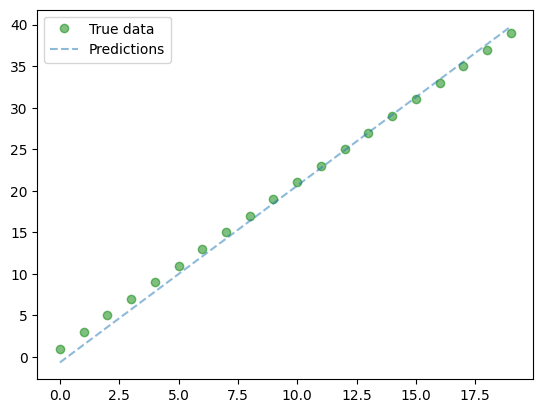

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Clear the current figure.
plt.clf()
# Plot the true data points in green circles.
plt.plot(x_train, y_train, 'go', label='True data', alpha=0.5)
# Plot the model's predictions as a dashed line.
plt.plot(x_train, predicted, '--', label='Predictions', alpha=0.5)
# Display the legend.
plt.legend(loc='best')
# Show the plot.
plt.show()


This section demonstrates how to implement a Logistic Regression model using PyTorch for binary classification, including data generation, model definition, training, and visualization of loss.

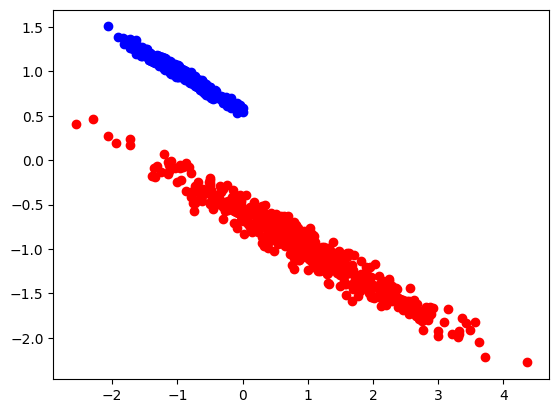

(1000, 2)
(1000,)


100%|██████████| 100000/100000 [00:42<00:00, 2338.41it/s]


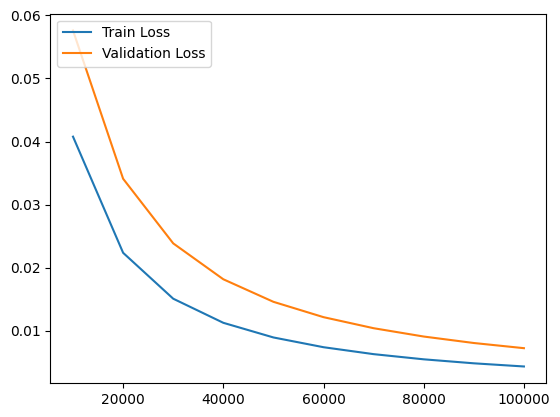

In [ ]:
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
import torch

from sklearn.datasets import make_classification

# 1. Data Generation
# Generate a random dataset for binary classification. The loop ensures the data is linearly separable.
separable = False
while not separable:
    samples = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1)
    red = samples[0][samples[1] == 0] # Class 0 data points
    blue = samples[0][samples[1] == 1] # Class 1 data points
    # Check if the classes are linearly separable.
    separable = any([red[:,k].max() < blue[:,k].min() or red[:,k].min() > blue[:,k].max() for k in range(2)])

# Plot the generated data points, colored by their class.
plt.scatter(red[:,0], red[:,1], c='red', label='Class 0')
plt.scatter(blue[:,0], blue[:,1], c='blue', label='Class 1')
plt.show()

# Assign labels to the data points.
red_labels = np.zeros(len(red))
blue_labels = np.ones(len(blue))

labels = np.append(red_labels, blue_labels)
inputs = np.concatenate((red, blue), axis=0)

# Print the shapes of the generated inputs and labels.
print (inputs.shape)
print (labels.shape)

# Split the data into training and validation sets.
X_train, X_val, y_train, y_val = train_test_split(inputs, labels, test_size=0.3, random_state=42)

# 2. Model Definition
# Define a Logistic Regression model using torch.nn.Module.
class LogisticRegression (torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        # Linear layer for transformation.
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        # Apply sigmoid activation function to the output of the linear layer.
        out = torch.sigmoid(self.linear(x))
        return out

# Set hyperparameters.
epochs = 100000
input_dim = 2 # Two features: x1, x2
output_dim = 1 # One output (probability of belonging to class 1)
learning_rate = 0.01

# Instantiate the model.
model = LogisticRegression(input_dim, output_dim)

# 3. Loss Function and Optimizer
# Define the Binary Cross Entropy (BCE) loss function.
criterion = torch.nn.BCELoss()
# Define the Stochastic Gradient Descent (SGD) optimizer.
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Convert NumPy arrays to PyTorch tensors and float type.
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_val = torch.from_numpy(X_val).float()
y_val = torch.from_numpy(y_val).float()

# Lists to store losses for plotting.
losses = []
losses_val = []
iters = []
iter = 0

# 4. Training Loop
# Iterate over the specified number of epochs with a progress bar.
for epoch in tqdm(range(epochs)):
    # Clear gradients from the previous epoch.
    optimizer.zero_grad()
    # Perform a forward pass on the training data.
    outputs = model(X_train)
    # Calculate the loss on the training data.
    loss = criterion(torch.squeeze(outputs), y_train)
    # Perform a backward pass to compute gradients.
    loss.backward()
    # Update model parameters.
    optimizer.step()
    iter += 1
    # Evaluate and record loss every 10,000 iterations.
    if iter % 10000 == 0:
        with torch.no_grad(): # Disable gradient computation for validation.
            # Perform a forward pass on the validation data.
            outputs_val = model(X_val)
            # Calculate the loss on the validation data.
            loss_val = criterion(torch.squeeze(outputs_val), y_val)
            losses_val.append(loss_val.item())
            losses.append(loss.item())
            iters.append(iter)

# 5. Visualize Loss
# Clear the current figure.
plt.clf()
# Plot training and validation losses over iterations.
plt.plot(iters, losses, label='Train Loss')
plt.plot(iters, losses_val, label='Validation Loss')
# Display the legend.
plt.legend(loc="upper left")
# Show the plot.
plt.show()


This section demonstrates the implementation of a shallow neural network for binary classification. It covers data generation, model definition, training process, and evaluation.

(4000, 2)
(4000,)


Text(0, 0.5, 'feature 2')

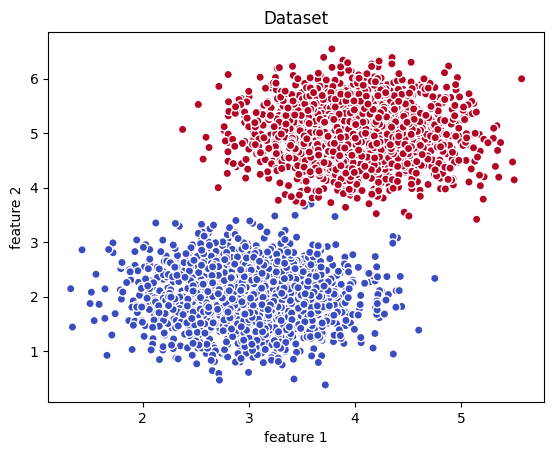

In [ ]:
# Necessary imports
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# This line detects if we have GPU support on our system
device = ("cuda" if torch.cuda.is_available() else "cpu")

# 1. Data Generation
# Generate two clusters of data points for feature 1 and feature 2.
x1 = np.random.randn(2000)*0.5+3
x2 = np.random.randn(2000)*0.5+2

x3 = np.random.randn(2000) *0.5 + 4
x4 = np.random.randn(2000) *0.5 + 5

# Create two classes of data by stacking x1,x2 and x3,x4.
X_1 = np.vstack([x1, x2])
X_2 = np.vstack([x3, x4])
# Combine the two classes into a single dataset X.
X = np.hstack([X_1, X_2]).T

# Create a vector that contains classes (0, 1) for the respective data points.
y = np.hstack([np.zeros(2000), np.ones(2000)])

# Print the shapes of the generated data.
print(X.shape)
print(y.shape)

# Visualize the dataset using a scatter plot.
plt.scatter(X[:,0], X[:,1], c=y, cmap=cm.coolwarm, edgecolors='w');
plt.title('Dataset')
plt.xlabel('feature 1')
plt.ylabel('feature 2')

In [ ]:
# Split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# Convert NumPy arrays into PyTorch tensors of type float.
X_train = torch.from_numpy(X_train).type(torch.FloatTensor)
X_test = torch.from_numpy(X_test).type(torch.FloatTensor)

# Convert y_train and y_test to PyTorch tensors, ensuring they have the correct shape (N, 1).
y_train = torch.from_numpy(y_train.squeeze()).type(torch.FloatTensor).view(-1, 1)
y_test = torch.from_numpy(y_test.squeeze()).type(torch.FloatTensor).view(-1, 1)

# Print the shapes of the processed tensors.
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

torch.Size([3200, 2])
torch.Size([800, 2])
torch.Size([3200, 1])
torch.Size([800, 1])


This markdown cell introduces the model definition part of the shallow neural network. It highlights the architecture and components of the model.

In [ ]:
class ShallowNeuralNetwork(nn.Module):
    def __init__(self, input_num, hidden_num, output_num):
        super(ShallowNeuralNetwork, self).__init__()
        # Define the hidden layer with input_num features and hidden_num output features.
        self.hidden = nn.Linear(input_num, hidden_num)
        # Define the output layer with hidden_num input features and output_num output features.
        self.output = nn.Linear(hidden_num, output_num)
        # Define the ReLU activation function to be used in the hidden layer.
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass the input through the hidden layer and apply the ReLU activation.
        x = self.relu(self.hidden(x))
        # Pass the result through the output layer.
        out = self.output(x)
        return out

# Define the number of input features, hidden units, and output features.
input_num = 2  # Corresponds to the two features (x and y coordinates) in our dataset.
hidden_num = 2 # Number of neurons in the hidden layer.
output_num = 1 # The output should be 1 for binary classification (probability of class 1).

# Instantiate the ShallowNeuralNetwork model.
model = ShallowNeuralNetwork(input_num, hidden_num, output_num)
# Move our model to GPU if available, otherwise use CPU.
model.to(device)
# Print the model architecture.
print(model)

ShallowNeuralNetwork(
  (hidden): Linear(in_features=2, out_features=2, bias=True)
  (output): Linear(in_features=2, out_features=1, bias=True)
  (relu): ReLU()
)


This section details the training process of the shallow neural network. It includes setting up the loss function, optimizer, and the training loop.

In [ ]:
# Import tqdm for displaying a progress bar during training.
from tqdm import tqdm

# Define the loss function: Binary Cross Entropy with Logits Loss, suitable for binary classification.
criterion = torch.nn.BCEWithLogitsLoss()
# Define the optimizer: Stochastic Gradient Descent (SGD) with a learning rate of 0.1.
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

# Move training and testing data to GPU if available.
if torch.cuda.is_available():
    X_train = Variable(X_train).cuda()
    y_train = Variable(y_train).cuda()
    X_test = Variable(X_test).cuda()
    y_test = Variable(y_test).cuda()

# Define the number of training epochs.
num_epochs = 1000

# Initialize lists to store metrics (though not fully utilized in this snippet).
total_acc, total_loss = [], []

# Start the training loop.
for epoch in tqdm(range(num_epochs)):
    # Set the model to training mode.
    model.train()

    # Perform a forward pass to get predictions.
    y_pred = model(X_train)
    # Convert predictions to binary (0 or 1) based on a threshold of 0.5 (for logging/accuracy, though BCEWithLogitsLoss expects raw logits).
    pred = np.where(y_pred.cpu() > 0.5, 1, 0)
    # Calculate the loss between predictions and actual labels.
    loss = criterion(y_pred, y_train)

    # Perform backpropagation.
    # Clear previous gradients.
    optimizer.zero_grad()
    # Compute gradients of the loss with respect to model parameters.
    loss.backward()
    # Update model parameters using the optimizer.
    optimizer.step()

    # Print training loss for the current epoch.
    print('Epoch [{}/{}], Train Loss: {:.5f},'.format(epoch, num_epochs, loss.item()))
print('\nTraining Complete')

 24%|██▎       | 237/1000 [00:00<00:00, 1198.90it/s]

Epoch [0/1000], Train Loss: 0.95331,
Epoch [1/1000], Train Loss: 0.84916,
Epoch [2/1000], Train Loss: 0.80211,
Epoch [3/1000], Train Loss: 0.77289,
Epoch [4/1000], Train Loss: 0.74671,
Epoch [5/1000], Train Loss: 0.71574,
Epoch [6/1000], Train Loss: 0.70269,
Epoch [7/1000], Train Loss: 0.70171,
Epoch [8/1000], Train Loss: 0.70114,
Epoch [9/1000], Train Loss: 0.70067,
Epoch [10/1000], Train Loss: 0.70026,
Epoch [11/1000], Train Loss: 0.69989,
Epoch [12/1000], Train Loss: 0.69954,
Epoch [13/1000], Train Loss: 0.69922,
Epoch [14/1000], Train Loss: 0.69891,
Epoch [15/1000], Train Loss: 0.69862,
Epoch [16/1000], Train Loss: 0.69835,
Epoch [17/1000], Train Loss: 0.69808,
Epoch [18/1000], Train Loss: 0.69784,
Epoch [19/1000], Train Loss: 0.69760,
Epoch [20/1000], Train Loss: 0.69738,
Epoch [21/1000], Train Loss: 0.69717,
Epoch [22/1000], Train Loss: 0.69697,
Epoch [23/1000], Train Loss: 0.69679,
Epoch [24/1000], Train Loss: 0.69661,
Epoch [25/1000], Train Loss: 0.69644,
Epoch [26/1000], Train

 49%|████▉     | 493/1000 [00:00<00:00, 1234.18it/s]

Epoch [262/1000], Train Loss: 0.69315,
Epoch [263/1000], Train Loss: 0.69315,
Epoch [264/1000], Train Loss: 0.69315,
Epoch [265/1000], Train Loss: 0.69315,
Epoch [266/1000], Train Loss: 0.69315,
Epoch [267/1000], Train Loss: 0.69315,
Epoch [268/1000], Train Loss: 0.69315,
Epoch [269/1000], Train Loss: 0.69315,
Epoch [270/1000], Train Loss: 0.69315,
Epoch [271/1000], Train Loss: 0.69315,
Epoch [272/1000], Train Loss: 0.69315,
Epoch [273/1000], Train Loss: 0.69315,
Epoch [274/1000], Train Loss: 0.69315,
Epoch [275/1000], Train Loss: 0.69315,
Epoch [276/1000], Train Loss: 0.69315,
Epoch [277/1000], Train Loss: 0.69315,
Epoch [278/1000], Train Loss: 0.69315,
Epoch [279/1000], Train Loss: 0.69315,
Epoch [280/1000], Train Loss: 0.69315,
Epoch [281/1000], Train Loss: 0.69315,
Epoch [282/1000], Train Loss: 0.69315,
Epoch [283/1000], Train Loss: 0.69315,
Epoch [284/1000], Train Loss: 0.69315,
Epoch [285/1000], Train Loss: 0.69315,
Epoch [286/1000], Train Loss: 0.69315,
Epoch [287/1000], Train L

 74%|███████▍  | 743/1000 [00:00<00:00, 1215.21it/s]

Epoch [519/1000], Train Loss: 0.69315,
Epoch [520/1000], Train Loss: 0.69315,
Epoch [521/1000], Train Loss: 0.69315,
Epoch [522/1000], Train Loss: 0.69315,
Epoch [523/1000], Train Loss: 0.69315,
Epoch [524/1000], Train Loss: 0.69315,
Epoch [525/1000], Train Loss: 0.69315,
Epoch [526/1000], Train Loss: 0.69315,
Epoch [527/1000], Train Loss: 0.69315,
Epoch [528/1000], Train Loss: 0.69315,
Epoch [529/1000], Train Loss: 0.69315,
Epoch [530/1000], Train Loss: 0.69315,
Epoch [531/1000], Train Loss: 0.69315,
Epoch [532/1000], Train Loss: 0.69315,
Epoch [533/1000], Train Loss: 0.69315,
Epoch [534/1000], Train Loss: 0.69315,
Epoch [535/1000], Train Loss: 0.69315,
Epoch [536/1000], Train Loss: 0.69315,
Epoch [537/1000], Train Loss: 0.69315,
Epoch [538/1000], Train Loss: 0.69315,
Epoch [539/1000], Train Loss: 0.69315,
Epoch [540/1000], Train Loss: 0.69315,
Epoch [541/1000], Train Loss: 0.69315,
Epoch [542/1000], Train Loss: 0.69315,
Epoch [543/1000], Train Loss: 0.69315,
Epoch [544/1000], Train L

100%|██████████| 1000/1000 [00:00<00:00, 1221.97it/s]

Epoch [754/1000], Train Loss: 0.69315,
Epoch [755/1000], Train Loss: 0.69315,
Epoch [756/1000], Train Loss: 0.69315,
Epoch [757/1000], Train Loss: 0.69315,
Epoch [758/1000], Train Loss: 0.69315,
Epoch [759/1000], Train Loss: 0.69315,
Epoch [760/1000], Train Loss: 0.69315,
Epoch [761/1000], Train Loss: 0.69315,
Epoch [762/1000], Train Loss: 0.69315,
Epoch [763/1000], Train Loss: 0.69315,
Epoch [764/1000], Train Loss: 0.69315,
Epoch [765/1000], Train Loss: 0.69315,
Epoch [766/1000], Train Loss: 0.69315,
Epoch [767/1000], Train Loss: 0.69315,
Epoch [768/1000], Train Loss: 0.69315,
Epoch [769/1000], Train Loss: 0.69315,
Epoch [770/1000], Train Loss: 0.69315,
Epoch [771/1000], Train Loss: 0.69315,
Epoch [772/1000], Train Loss: 0.69315,
Epoch [773/1000], Train Loss: 0.69315,
Epoch [774/1000], Train Loss: 0.69315,
Epoch [775/1000], Train Loss: 0.69315,
Epoch [776/1000], Train Loss: 0.69315,
Epoch [777/1000], Train Loss: 0.69315,
Epoch [778/1000], Train Loss: 0.69315,
Epoch [779/1000], Train L

Accuracy Score on test data ==>> 49.625%


/tmp/ipykernel_21030/2973914907.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='Class 0', cmap=cm.coolwarm)
/tmp/ipykernel_21030/2973914907.py:31: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='Class 1', cmap=cm.coolwarm)
/tmp/ipykernel_21030/2973914907.py:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(X_test[model_prediction==0, 0], X_test[model_prediction==0, 1], label='Class 0', cmap=cm.coolwarm)
/tmp/ipykernel_21030/2973914907.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(X_test[model_prediction==1, 0], X_test[model_prediction==1, 1], label='Class 1', cmap=cm.coolwarm)


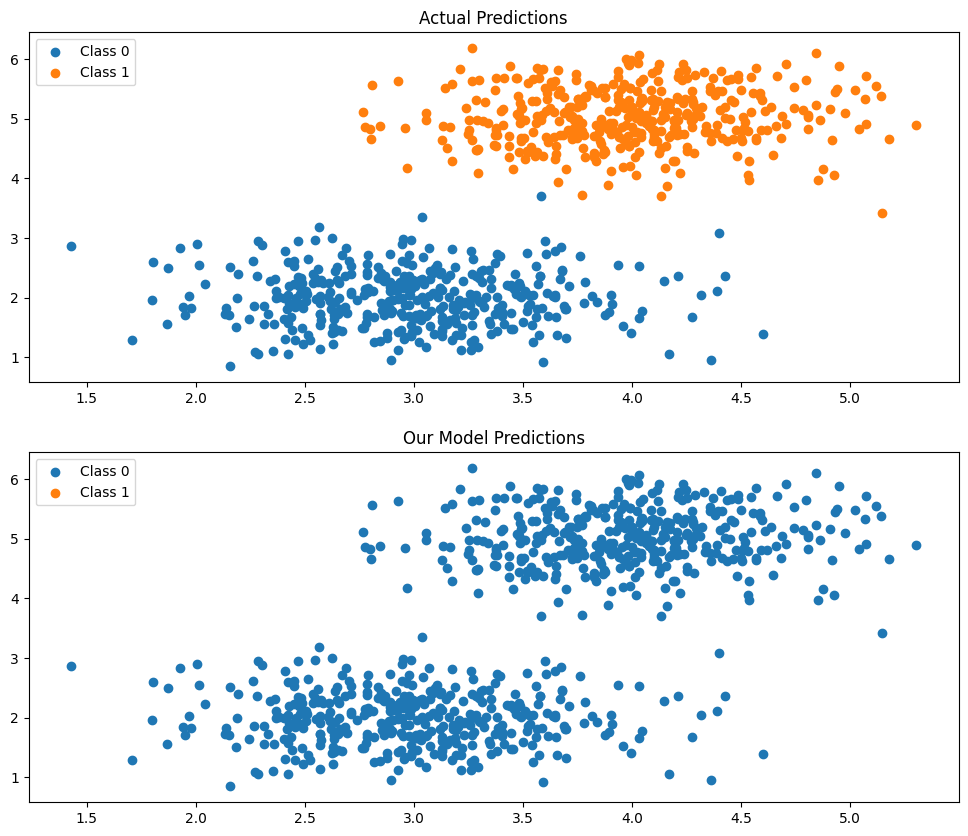

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set the model to evaluation mode (disables dropout, batchnorm updates, etc.).
model.eval()
# Get model predictions on the test data.
model_prediction = model(X_test)

# Convert raw logits to binary predictions (0 or 1) based on a threshold of 0.5.
model_prediction = np.where(model_prediction.cpu() > 0.5, 1, 0)
# Reshape the predictions to a 1D array.
model_prediction = model_prediction.reshape(-1)
# Calculate and print the accuracy score on the test data.
print("Accuracy Score on test data ==>> {}%".format(accuracy_score(model_prediction, y_test.cpu()) * 100))

# Move y_test and X_test back to CPU for plotting.
y_test = y_test.cpu()
X_test = X_test.cpu()

# Create a figure with two subplots for visualization.
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
# Reshape y_test to a 1D array for indexing.
y_test = y_test.view(-1)

# Plot True Predictions (Actual Data)
# Scatter plot for Class 0 (actual labels).
ax[0].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='Class 0', cmap=cm.coolwarm)
# Scatter plot for Class 1 (actual labels).
ax[0].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='Class 1', cmap=cm.coolwarm)
ax[0].set_title('Actual Predictions')
ax[0].legend()

# Plot Model's Predictions
# Scatter plot for Class 0 (model's predictions).
ax[1].scatter(X_test[model_prediction==0, 0], X_test[model_prediction==0, 1], label='Class 0', cmap=cm.coolwarm)
# Scatter plot for Class 1 (model's predictions).
ax[1].scatter(X_test[model_prediction==1, 0], X_test[model_prediction==1, 1], label='Class 1', cmap=cm.coolwarm)
ax[1].set_title('Our Model Predictions')
ax[1].legend()